<a href="https://colab.research.google.com/github/mvuddandi/Capstone_PatchTST/blob/main/Features_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! git clone https://github.com/mvuddandi/Capstone_PatchTST.git

Cloning into 'Capstone_PatchTST'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 33 (delta 14), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 7.98 MiB | 5.29 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [2]:
%cd /content/Capstone_PatchTST


/content/Capstone_PatchTST


In [3]:
import pandas as pd
df = pd.read_csv("/content/Capstone_PatchTST/weather.csv")

In [4]:
df.columns

Index(['date', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
       'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)', 'rain (mm)', 'raining (s)', 'SWDR (W/m�)',
       'PAR (�mol/m�/s)', 'max. PAR (�mol/m�/s)', 'Tlog (degC)', 'OT'],
      dtype='object')

In [7]:
import numpy as np
import pandas as pd

target = "T (degC)"   # change this to any column you want

df_num = df.select_dtypes(include=[np.number]).copy()
df_num = df_num.replace([np.inf, -np.inf], np.nan).dropna()

pearson = df_num.corr(method="pearson")[target].sort_values(
    key=lambda s: s.abs(), ascending=False
)
spearman = df_num.corr(method="spearman")[target].sort_values(
    key=lambda s: s.abs(), ascending=False
)

result = pd.DataFrame({
    "pearson_corr": pearson,
    "spearman_corr": spearman
})

result


,pearson_corr,spearman_corr
H2OC (mmol/mol),0.761934,0.808874
OT,-0.039150,-0.554148
PAR (�mol/m�/s),0.459806,0.415097
SWDR (W/m�),0.448607,0.401805
T (degC),1.000000,1.000000
Tdew (degC),0.782740,0.809700
Tlog (degC),0.981562,0.983058
Tpot (K),0.995228,0.994495
VPact (mbar),0.762860,0.809700
VPdef (mbar),0.779616,0.730476


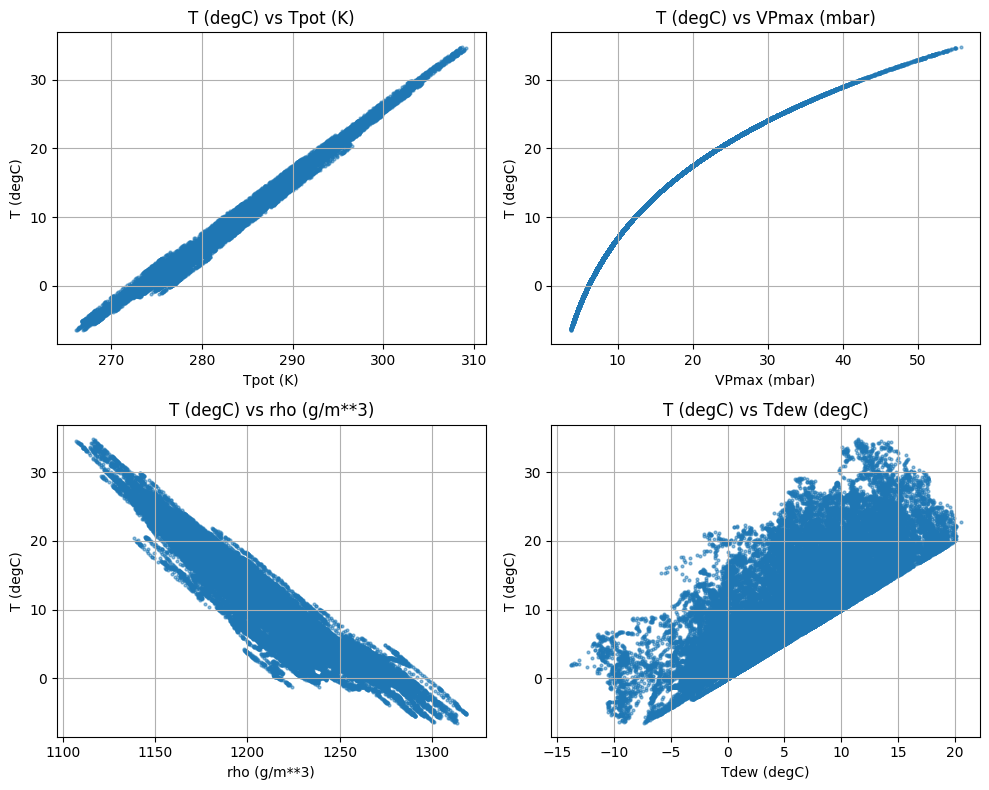

In [8]:
import matplotlib.pyplot as plt

target = "T (degC)"

top_features = [
    "Tpot (K)",
    "VPmax (mbar)",
    "rho (g/m**3)",
    "Tdew (degC)"
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    ax.scatter(df[feat], df[target], s=4, alpha=0.5)
    ax.set_xlabel(feat)
    ax.set_ylabel(target)
    ax.set_title(f"{target} vs {feat}")
    ax.grid(True)

plt.tight_layout()
plt.show()
